<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Perceptron_part_2(Tricks).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
from sklearn.datasets import make_classification
import numpy as np
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_classes=2,n_clusters_per_class=1,n_redundant=0,random_state=41,hypercube=False,class_sep=10)



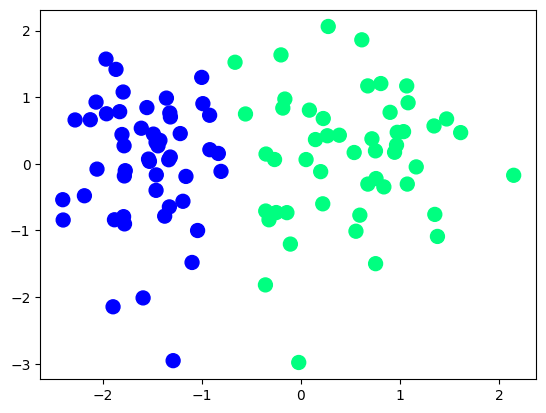

In [52]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [53]:
 X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [54]:
X.shape

(100, 2)

In [55]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [56]:
def perceptron(X,y):
  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.1

  for i in range(1000):
    j=np.random.randint(0,100)
    y_hat=step(np.dot(X[j],weights))
    weights=weights+lr*(y[j]-y_hat)*X[j]
  return weights[0],weights[1:]

The `perceptron` function implements a basic perceptron algorithm for binary classification. Here's a breakdown of its components:

*   **`X=np.insert(X,0,1,axis=1)`**: This line adds a bias term to the input features `X`. A column of ones is inserted at the beginning (index 0) of the `X` array. This allows the perceptron to learn an intercept (bias) in its decision boundary.
*   **`weights=np.ones(X.shape[1])`**: Initializes the weight vector. The number of weights is equal to the number of features in `X` (including the bias term), and they are all initialized to 1.
*   **`lr=0.1`**: Sets the learning rate, which controls the step size during weight updates. A value of 0.1 means that weights will be adjusted by 10% of the calculated error multiplied by the input feature value.
*   **`for i in range(1000):`**: The perceptron iterates 1000 times to learn the optimal weights. In each iteration, it performs stochastic gradient descent (SGD).
*   **`j=np.random.randint(0,100)`**: A random data point (`j`) is selected from the dataset `X` for training. This is the 'stochastic' part of SGD.
*   **`y_hat=step(np.dot(X[j],weights))`**: Calculates the predicted output (`y_hat`) for the selected data point.
    *   `np.dot(X[j],weights)` computes the dot product of the input features of the selected data point (`X[j]`) and the current weights. This is the linear combination of inputs and weights.
    *   `step(...)` is an activation function (defined elsewhere as `return 1 if z > 0 else 0`), which converts the linear combination into a binary prediction (0 or 1).
*   **`weights=weights+lr*(y[j]-y_hat)*X[j]`**: This is the core weight update rule of the perceptron algorithm.
    *   `(y[j]-y_hat)` calculates the error, which is the difference between the actual label (`y[j]`) and the predicted label (`y_hat`).
    *   This error is multiplied by the learning rate (`lr`) and the input features (`X[j]`) to determine the magnitude and direction of the weight adjustment.
*   **`return weights[0],weights[1:]`**: After 1000 iterations, the function returns the learned bias term (the first element of `weights`) and the rest of the weights as the feature coefficients.

In [70]:
intercept_,coef_=perceptron(X,y)

In [58]:
print(intercept_)
print(coef_)

0.9
[1.25966565 0.20983574]


In [59]:
m=-coef_[0]/coef_[1]
b=-intercept_/coef_[1]

In [60]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+b

(-3.0, 2.0)

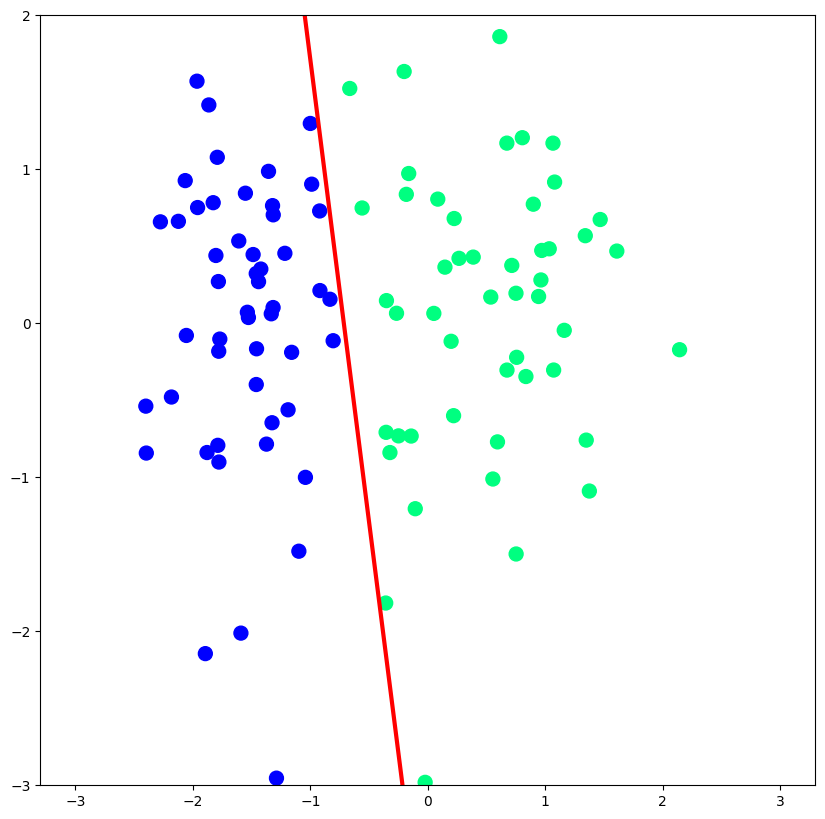

In [61]:
plt.figure(figsize=(10,10))
plt.plot(x_input, y_input, color='red', linewidth=3)

plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)

In [62]:
np.insert(X,0,1,axis=1)

array([[ 1.        ,  0.19924745, -0.11697552],
       [ 1.        , -0.24882029, -0.73115232],
       [ 1.        , -0.3544904 , -0.7081059 ],
       [ 1.        , -1.59086506, -2.01199214],
       [ 1.        , -0.20083951,  1.63493163],
       [ 1.        , -0.83241122,  0.15599044],
       [ 1.        , -1.79207014,  1.07782053],
       [ 1.        ,  0.0856607 ,  0.80626713],
       [ 1.        , -0.55865299,  0.74859527],
       [ 1.        , -1.95974262,  0.75152794],
       [ 1.        , -1.77828947, -0.90114581],
       [ 1.        , -1.77985853, -0.1815243 ],
       [ 1.        , -0.02194151, -2.98092432],
       [ 1.        ,  0.80563431,  1.20500136],
       [ 1.        , -1.82701214,  0.78302407],
       [ 1.        ,  0.38730728,  0.42968688],
       [ 1.        , -0.14108668, -0.73229726],
       [ 1.        , -1.87955941, -0.83930476],
       [ 1.        , -0.18232911,  0.83727062],
       [ 1.        , -1.77059533, -0.10255323],
       [ 1.        , -2.27658028,  0.658

In [63]:
weight=np.ones(X.shape[1] +1)
weight

array([1., 1., 1.])

In [64]:
np.ones(3)

array([1., 1., 1.])

In [65]:
np.random.randint(0,100)

13

In [66]:
np.dot(np.insert(X[37],0,1),[1,1,1])

np.float64(2.843765513760431)

In [67]:
def step(z):
  return 1 if z >0 else 0

In [68]:
step(2.84376)

1

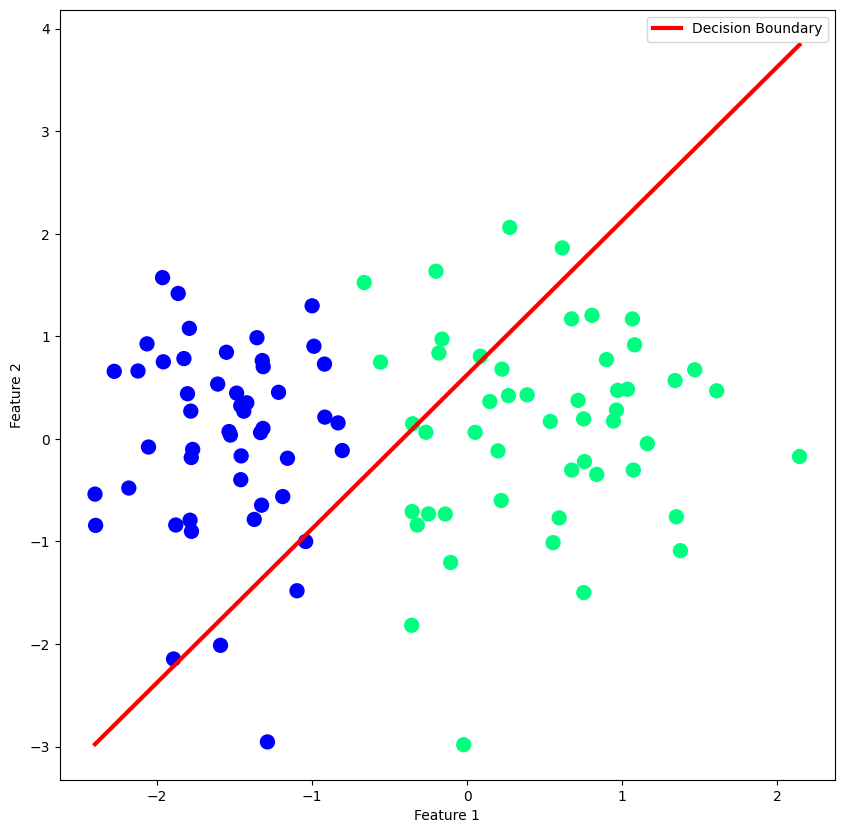

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Example: assume model weights (replace with your trained model values)
w1 = 1.2
w2 = -0.8
b = 0.5

# Generate x values
x_input = np.linspace(X[:,0].min(), X[:,0].max(), 100)

# Decision boundary equation
y_input = -(w1/w2) * x_input - (b/w2)

# Plot
plt.figure(figsize=(10,10))

# Decision boundary line
plt.plot(x_input, y_input, color='red', linewidth=3, label='Decision Boundary')

# Scatter plot
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()